### Student Name: Andrianov Aleksandr
### Student ID: 20033313

Dataset: https://github.com/luminati-io/Social-media-dataset-samples/blob/main/Twitter-%20datasets.csv?h=1

In [42]:
import pandas as pd

def read_and_summarize_dataframe(df_name):
    df = pd.read_csv(df_name)

    print("----- Dataframe Information -----")
    print(df.info(), "\n")

    print("----- Dataset Shape -----")
    print(df.shape, "\n")

    print("----- Data Types -----")
    print(df.dtypes, "\n")

    print("----- Columns -----")
    print(df.columns, "\n")

    print("----- Statistics -----")
    print(df.describe(), "\n")

    print("----- Missing Values Per Column -----")
    print(df.isnull().sum(), "\n")

    print("----- Total Missing Values -----")
    print(df.isnull().sum().sum(), "\n")

    print("----- Unique Values Per Column -----")
    print(df.nunique(), "\n")

    print("----- First 5 Rows -----")
    print([df[col].head(5).tolist() for col in df.columns])

    return df

In [43]:
df_twitter = read_and_summarize_dataframe("Twitter- datasets.csv")

----- Dataframe Information -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   1000 non-null   int64 
 1   user_posted          1000 non-null   object
 2   name                 1000 non-null   object
 3   description          1000 non-null   object
 4   date_posted          1000 non-null   object
 5   photos               456 non-null    object
 6   url                  1000 non-null   object
 7   tagged_users         374 non-null    object
 8   replies              1000 non-null   int64 
 9   reposts              1000 non-null   int64 
 10  likes                1000 non-null   int64 
 11  views                1000 non-null   int64 
 12  external_url         432 non-null    object
 13  hashtags             572 non-null    object
 14  followers            1000 non-null   int64 
 15  biography            9

# 2. Data Preprocessing

## 2.1. Selection interesting features

In [44]:
df = df_twitter[['id', 'description', 'hashtags']]
df['description'] = df['description'].astype(str)

/var/folders/7h/ywl51fkn3mjc6tr44bbfj2z80000gn/T/ipykernel_95208/1258339334.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['description'] = df['description'].astype(str)


## 2.2. Filtering only English posts

In [45]:
from langdetect import detect
from tqdm import tqdm
tqdm.pandas()

def is_english(text):
    try:
        lang = detect(text)
        return lang == "en"
    except:
        return False

df['is_english'] = df['description'].progress_apply(is_english)
df = df[df['is_english'] == True].reset_index(drop=True)

print("Number of English tweets remaining:", len(df))

100%|██████████| 1000/1000 [00:01<00:00, 905.80it/s]

Number of English tweets remaining: 683



/var/folders/7h/ywl51fkn3mjc6tr44bbfj2z80000gn/T/ipykernel_95208/2801930525.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_english'] = df['description'].progress_apply(is_english)


## 2.3. Text cleaning

In [46]:
import emoji
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['clean_text'] = df['description'].apply(clean_text)

## 2.4. TF-IDF Vectorizer

TF-IDF Vectorizer converts text into numerical features by measuring how important each word is within a document and across the entire corpus. It works by computing TF (Term Frequency): how often a word appears in a document — and IDF (Inverse Document Frequency): how rare the word is across all documents. The TF and IDF values are then multiplied, producing a score that is high for words that are frequent in a specific document but rare in the corpus. As a result, TF-IDF emphasizes informative, topic-related terms while down-weighting common, non-informative words like “the” or “and,” allowing machine learning models to distinguish documents based on meaningful vocabulary.

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3
)

X_tfidf = vectorizer.fit_transform(df['clean_text'])

# 3. Clusterization

## 3.1. KMeans Clustring

K-Means clustering is an unsupervised learning algorithm that groups data into k clusters based on similarity. It works by repeatedly assigning each point to the nearest cluster center and then updating the centers as the mean of all points in each cluster. This process continues until the cluster assignments stop changing or the improvement becomes minimal. The goal is to minimize the overall distance between points and their assigned cluster centers, producing compact and well-separated groups.

In [48]:
from sklearn.cluster import KMeans

k = 10   # best elbow parameter
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X_tfidf)

## 3.2. Agglomerative Clustering

Agglomerative clustering is a hierarchical clustering method that builds clusters from the bottom up. It starts by treating each data point as an individual cluster and then repeatedly merges the two closest clusters based on a chosen distance metric. This continues until all points form one large cluster or until a specified number of clusters is reached. The result is often visualized with a dendrogram, which shows the structure and hierarchy of the merges.

In [49]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=k)
df['cluster_agg'] = agg.fit_predict(X_tfidf.toarray())

## 3.3. Sentence-BERT embeddings + KMeans

Sentence-BERT (SBERT) embeddings are dense numerical vector representations of sentences that capture their semantic meaning. Unlike traditional bag-of-words or TF-IDF features, SBERT maps sentences into a continuous vector space where semantically similar texts are located close to each other. It achieves this by fine-tuning a transformer model using a siamese architecture, enabling it to produce meaningful fixed-size embeddings that work well for semantic similarity, clustering, and retrieval tasks.

When combined with KMeans, SBERT embeddings allow clustering to operate on semantic meaning rather than on surface-level lexical features. KMeans then groups these embeddings into clusters by repeatedly assigning each embedding to the nearest cluster centroid and updating the centroids based on their assigned points. This makes the resulting clusters more coherent in content and topic, especially for tasks like tweet or document clustering where understanding semantic similarity is crucial.

In [50]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['clean_text'], show_progress_bar=True)

kmeans_sbert = KMeans(n_clusters=k, random_state=42)
df['cluster_sbert'] = kmeans_sbert.fit_predict(embeddings)

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

# 4. Accuracy metrics

## 4.1. Metrics based on hashtags

In [51]:
import ast

def parse_hashtags(x):
    try:
        arr = ast.literal_eval(x)
        if isinstance(arr, list):
            return [h.lower() for h in arr]
    except:
        return []
    return []

df['hashtags'] = df['hashtags'].astype(str).apply(parse_hashtags)

In [52]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_cluster_hashtags_pie(df, cluster_col='cluster', hashtags_col='hashtags'):

    clusters = sorted(df[cluster_col].unique())

    for cluster in clusters:
        cluster_df = df[df[cluster_col] == cluster]

        total_posts = len(cluster_df)

        hashtag_counts = Counter()
        for tags_list in cluster_df[hashtags_col]:
            hashtag_counts.update(set(tags_list))

        tags = list(hashtag_counts.keys())
        counts = list(hashtag_counts.values())

        if sum(counts) == 0:
            print(f"Cluster {cluster} (0 posts) — no hashtags to display.")
            continue

        freqs = [c / total_posts for c in counts]

        plt.figure(figsize=(5, 5))

        wedges, texts = plt.pie(
            freqs,
            labels=None,
            autopct=None,
            startangle=90
        )

        plt.legend(
            wedges,
            [f"{tag} ({count} posts)" for tag, count in zip(tags, counts)],
            title="Hashtags",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5)
        )

        plt.title(f"Cluster {cluster} ({total_posts} posts)", fontsize=14)

        plt.tight_layout()
        plt.show()

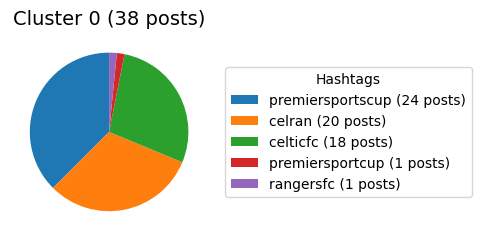

/var/folders/7h/ywl51fkn3mjc6tr44bbfj2z80000gn/T/ipykernel_95208/4030596636.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


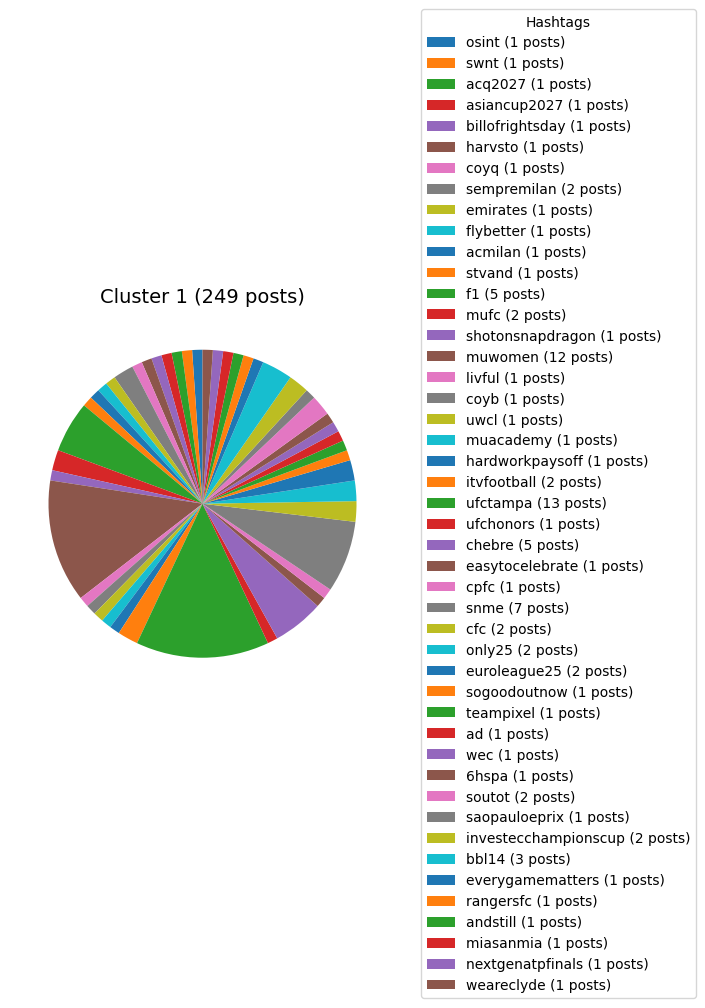

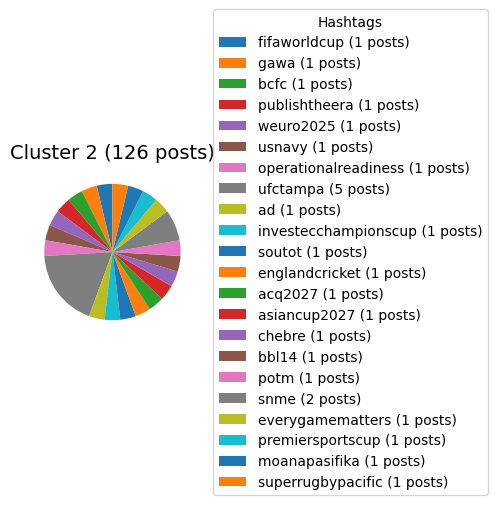

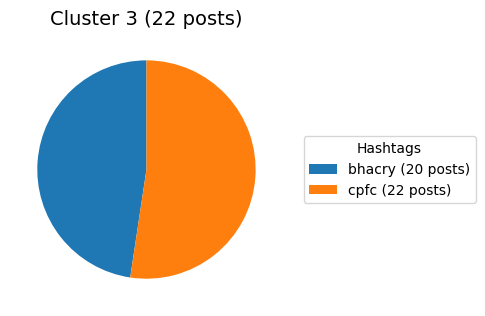

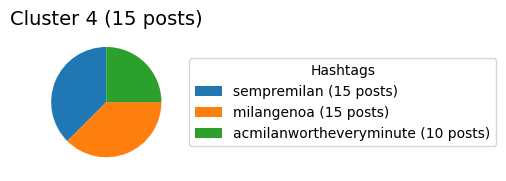

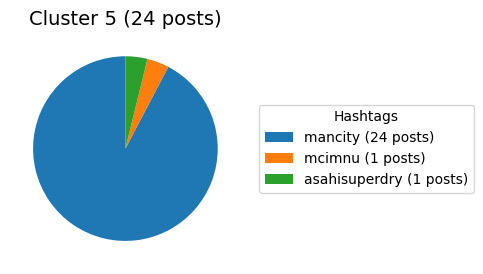

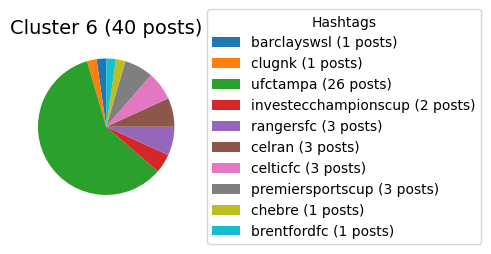

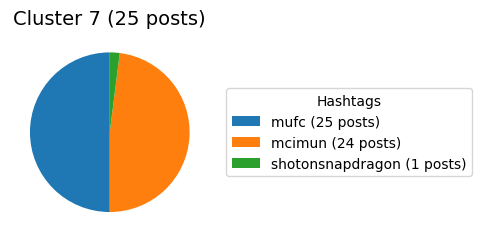

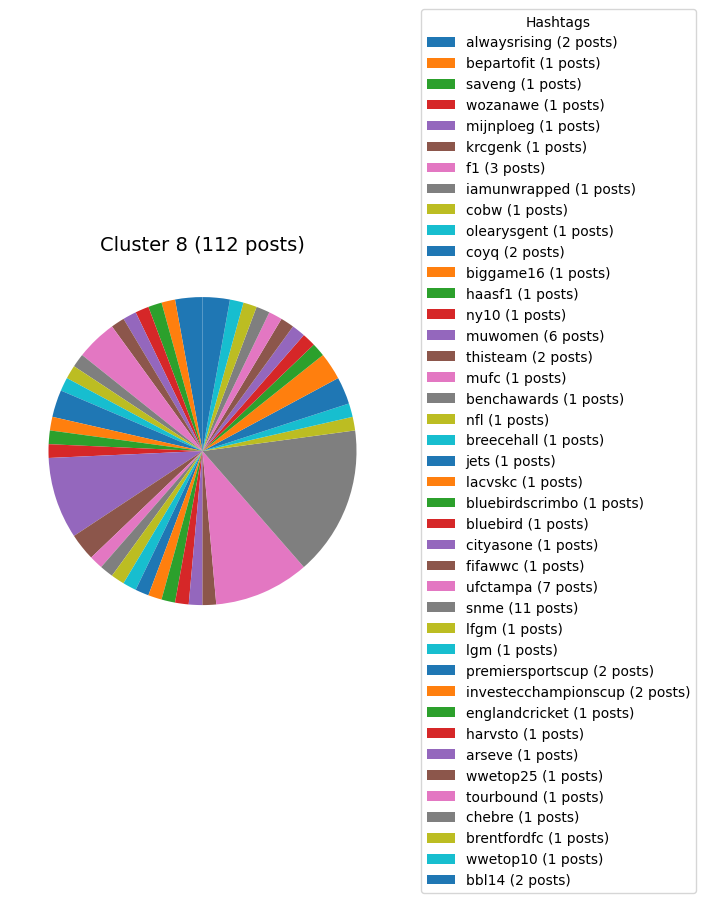

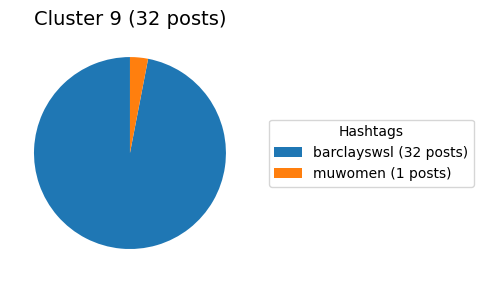

In [53]:
plot_cluster_hashtags_pie(df, cluster_col='cluster_kmeans', hashtags_col='hashtags')

/var/folders/7h/ywl51fkn3mjc6tr44bbfj2z80000gn/T/ipykernel_95208/4030596636.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


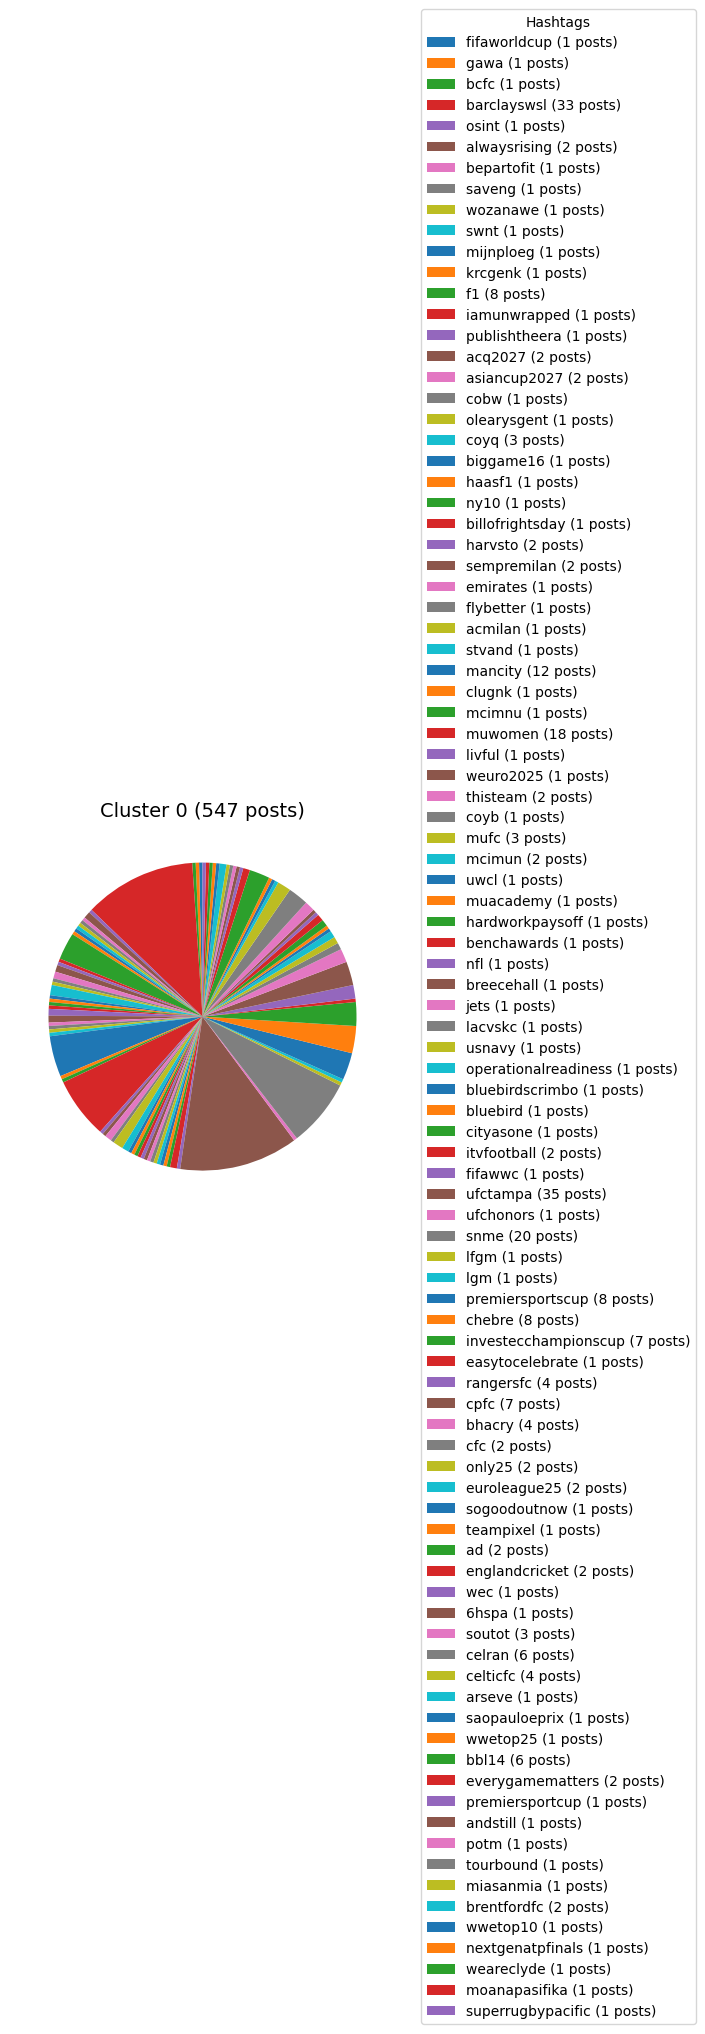

Cluster 1 (0 posts) — no hashtags to display.


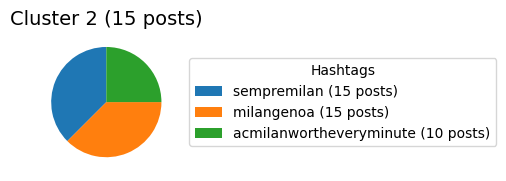

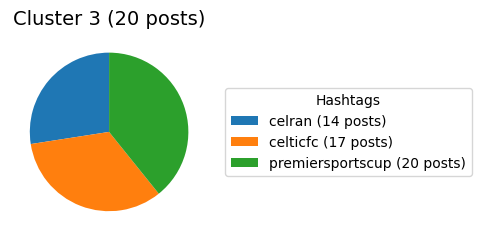

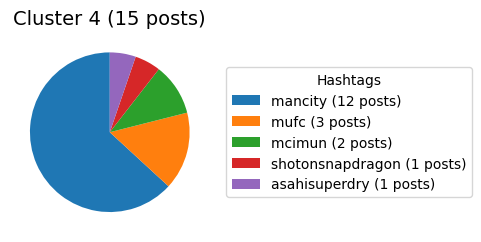

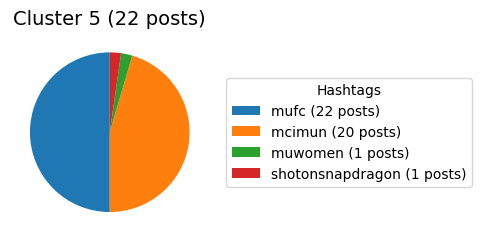

Cluster 6 (0 posts) — no hashtags to display.


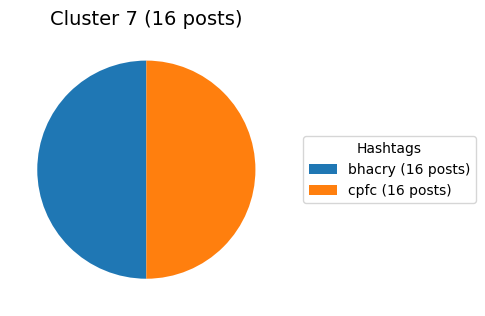

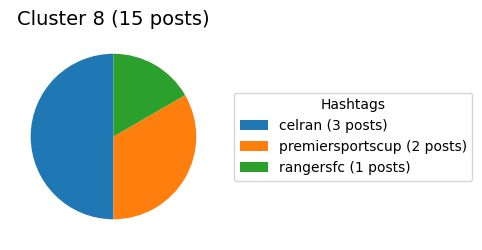

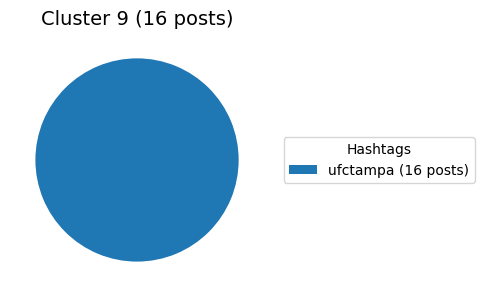

In [54]:
plot_cluster_hashtags_pie(df, cluster_col='cluster_agg', hashtags_col='hashtags')

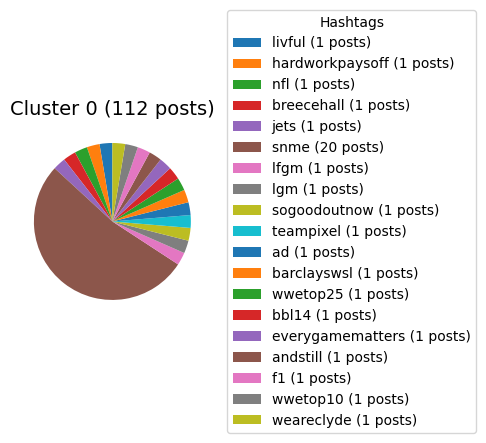

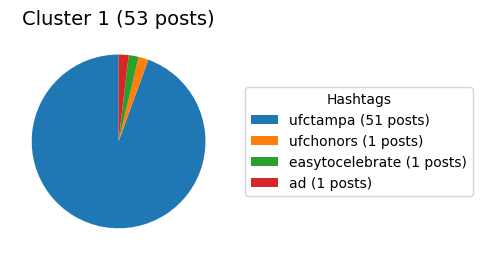

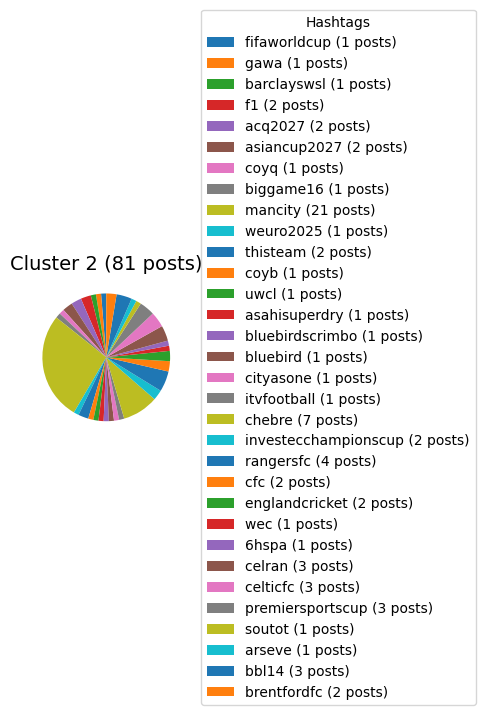

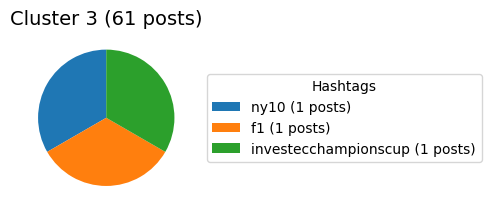

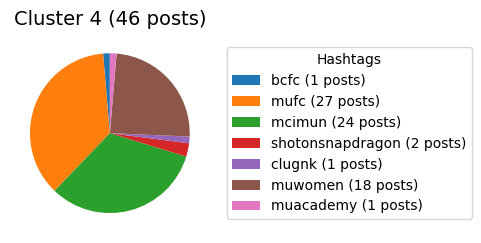

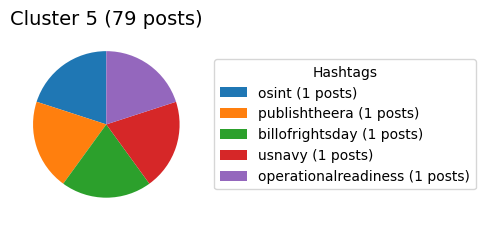

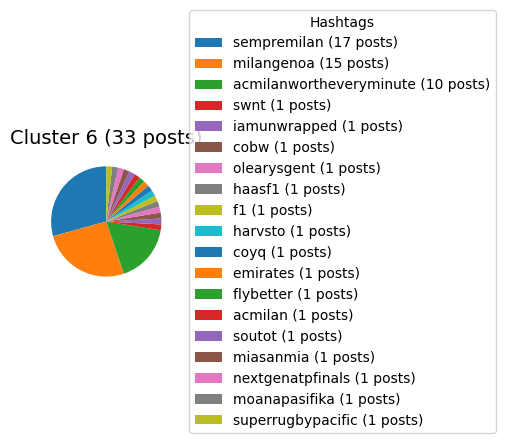

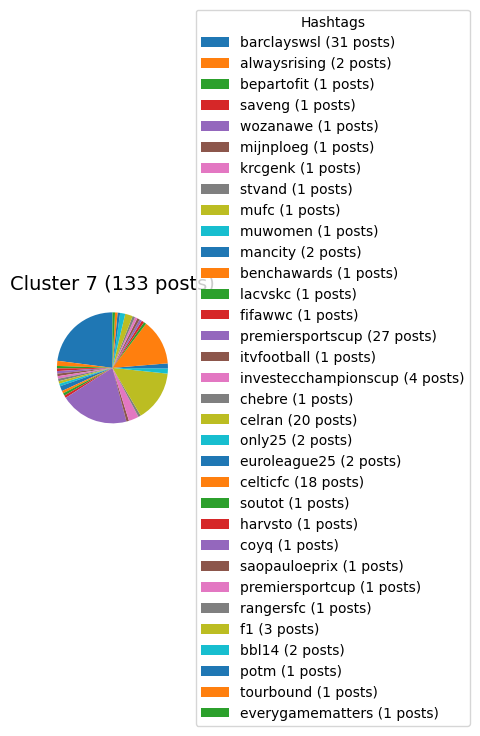

Cluster 8 (0 posts) — no hashtags to display.


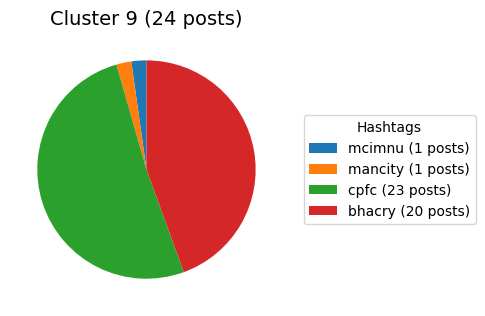

In [55]:
plot_cluster_hashtags_pie(df, cluster_col='cluster_sbert', hashtags_col='hashtags')

In [56]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def estimate_cluster_quality(df, cluster_col, X):
    labels = df[cluster_col]

    sil = silhouette_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    
    print(f"Silhouette Score:        {sil:.4f}")
    print(f"Calinski-Harabasz Score: {ch:.4f}")
    print(f"Davies-Bouldin Score:    {db:.4f}")

1. Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. Values close to 1.0 indicate that clusters are well-separated and compact. Scores between 0.25 and 0.5 suggest some structure but imperfect separation, while values below 0.25 indicate overlapping or poorly formed clusters. A negative score means many points are closer to another cluster than their own, implying a fundamentally incorrect clustering.

2. Calinski–Harabasz Index

The Calinski–Harabasz (CH) Index evaluates clustering quality by comparing how dispersed the cluster centers are relative to the compactness of points within each cluster. Higher values indicate better-defined and more separated clusters. This metric is primarily used to compare different values of k (number of clusters), not to judge absolute quality—higher is better relative to alternative clusterings.

3. Davies–Bouldin Index

The Davies–Bouldin (DB) Index measures the average similarity between each cluster and its most similar neighboring cluster. Lower values indicate better clustering, with 0–1.0 considered excellent and 1.0–2.0 acceptable. Values above 2.0 typically signal that clusters overlap or are poorly separated, while scores above 3.0 indicate a failed or meaningless clustering solution.

In [61]:
estimate_cluster_quality(df, cluster_col='cluster_kmeans', X=X_tfidf.toarray())

Silhouette Score:        0.0384
Calinski-Harabasz Score: 7.3963
Davies-Bouldin Score:    5.0764


In [62]:
estimate_cluster_quality(df, cluster_col='cluster_agg', X=X_tfidf.toarray())

Silhouette Score:        0.0326
Calinski-Harabasz Score: 6.8892
Davies-Bouldin Score:    2.7390


In [63]:

estimate_cluster_quality(df, cluster_col='cluster_sbert', X=embeddings)

Silhouette Score:        0.0438
Calinski-Harabasz Score: 14.9002
Davies-Bouldin Score:    3.9611


In [66]:
import pandas as pd
from collections import defaultdict

def hashtag_cluster_purity(df, cluster_col='cluster_kmeans'):

    hashtag_total = defaultdict(int)
    hashtag_cluster_count = defaultdict(lambda: defaultdict(int))

    for _, row in df.iterrows():
        cluster = row[cluster_col]
        for tag in row["hashtags"]:
            hashtag_total[tag] += 1
            hashtag_cluster_count[tag][cluster] += 1

    purities = {}
    for tag, total_count in hashtag_total.items():
        best_cluster_count = max(hashtag_cluster_count[tag].values())
        purities[tag] = best_cluster_count / total_count

    if len(purities) == 0:
        return 0, {}

    overall_quality = sum(purities.values()) / len(purities)
    return overall_quality

In [67]:
print(hashtag_cluster_purity(df, cluster_col='cluster_kmeans'))

0.9079653268220187


In [68]:
print(hashtag_cluster_purity(df, cluster_col='cluster_agg'))

0.9648038564985665


In [69]:
print(hashtag_cluster_purity(df, cluster_col='cluster_sbert'))

0.940816680680421
